In [3]:
import sys
from pathlib import Path


def _find_prototype_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (
            (candidate / "glass_pipeline").is_dir()
            and (candidate / "blackbox_pipeline").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        f"Could not locate prototype/ at or above {start}"
    )


PROTOTYPE_ROOT = _find_prototype_root(Path.cwd().resolve())

GLASS_ROOT = PROTOTYPE_ROOT / "glass_pipeline"
BLACKBOX_ROOT = PROTOTYPE_ROOT / "blackbox_pipeline"

assert (GLASS_ROOT / "data" / "bank_database.py").is_file(), (
    f"GLASS data package not found at {GLASS_ROOT / 'data'}"
)

# Add the PARENT of glass_pipeline so `import glass_pipeline...` works
if str(PROTOTYPE_ROOT) not in sys.path:
    sys.path.insert(0, str(PROTOTYPE_ROOT))

print("PROTOTYPE_ROOT:", PROTOTYPE_ROOT)
print("GLASS_ROOT:", GLASS_ROOT)
print("BLACKBOX_ROOT:", BLACKBOX_ROOT)

PROTOTYPE_ROOT: C:\Users\phill\projects\ai-business-coach\prototype
GLASS_ROOT: C:\Users\phill\projects\ai-business-coach\prototype\glass_pipeline
BLACKBOX_ROOT: C:\Users\phill\projects\ai-business-coach\prototype\blackbox_pipeline


In [4]:
from glass_pipeline.data import bank_database
from glass_pipeline.data.bank_database import DEFAULT_DB_PATH, RAW_TABLE, build_database, raw_bank_exists

# Make sure `data` resolved to GLASS, not another pipeline's package
assert GLASS_ROOT in Path(bank_database.__file__).resolve().parents, (
    f"`data` imported from {bank_database.__file__}; restart the kernel"
)

existed_before = raw_bank_exists(DEFAULT_DB_PATH)
DB_PATH = build_database()  # no-op when raw_bank exists; never passes rebuild=True

print(f"database: {DB_PATH}  ({'existing' if existed_before else 'built from CSV'})")

database: C:\Users\phill\projects\ai-business-coach\prototype\glass_pipeline\data\db\bank_marketing.db  (existing)


In [5]:
import sqlite3
from contextlib import closing

import pandas as pd

EXPECTED_ROWS    = 41_188  # bank-additional-full.csv
EXPECTED_N_COLS  = 21

# Read-only connection: this notebook must never modify the shared database
with closing(sqlite3.connect(DB_PATH.as_uri() + "?mode=ro", uri=True)) as conn:
    df_raw = pd.read_sql_query(f"SELECT * FROM {RAW_TABLE} ORDER BY rowid", conn)

assert len(df_raw) == EXPECTED_ROWS, f"Unexpected row count: {len(df_raw):,}"
assert df_raw.shape[1] == EXPECTED_N_COLS, f"Unexpected column count: {df_raw.shape[1]}"
assert df_raw["y"].isin(["yes", "no"]).all(), "Unexpected target values in raw_bank"

print(f"raw_bank: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(pd.DataFrame({
    "count": df_raw["y"].value_counts(),
    "share": df_raw["y"].value_counts(normalize=True).round(4),
}).to_string())

raw_bank: 41,188 rows × 21 columns
     count   share
y                 
no   36548  0.8873
yes   4640  0.1127


In [6]:
import io
from contextlib import redirect_stdout

from glass_pipeline.data.preprocessing.bank_preprocessing import BankPreprocessor
from glass_pipeline.data.global_splits.split_manager import GlobalSplitManager
from glass_pipeline.lr.feature_engineering import LR_FEATURES, engineer_features

LR_FEATURES = list(LR_FEATURES)

# GLASS modules print verbose logs; set True to see them
SHOW_GLASS_LOGS = False

def quiet(fn, *args, **kwargs):
    """Call a GLASS function, hiding its stdout unless SHOW_GLASS_LOGS is True."""
    if SHOW_GLASS_LOGS:
        return fn(*args, **kwargs)
    with redirect_stdout(io.StringIO()):
        return fn(*args, **kwargs)

In [7]:
import sys
for obj in (BankPreprocessor, GlobalSplitManager, engineer_features):
    print(f"{obj.__name__:<20} ← {sys.modules[obj.__module__].__file__}")
print("LR_FEATURES:", LR_FEATURES)

BankPreprocessor     ← C:\Users\phill\projects\ai-business-coach\prototype\glass_pipeline\data\preprocessing\bank_preprocessing.py
GlobalSplitManager   ← C:\Users\phill\projects\ai-business-coach\prototype\glass_pipeline\data\global_splits\split_manager.py
engineer_features    ← C:\Users\phill\projects\ai-business-coach\prototype\glass_pipeline\lr\feature_engineering.py
LR_FEATURES: ['cellular_crisis', 'euribor3m_local_rate', 'dow_month_encoded']


In [8]:
import numpy as np
import pandas as pd

RANDOM_STATE = 42

preprocessor = BankPreprocessor(drop_leaky=True, verbose=False)
df_processed = preprocessor.fit_transform()

split_manager = GlobalSplitManager(test_size=0.20, random_state=RANDOM_STATE)
GLOBAL_SPLIT  = quiet(split_manager.create_split, df_processed, target_col="y")

assert not set(BankPreprocessor.LEAKY_FEATURES) & set(GLOBAL_SPLIT["feature_names"])
print(f"GLOBAL_SPLIT: train {GLOBAL_SPLIT['X_train'].shape} | test {GLOBAL_SPLIT['X_test'].shape}")

GLOBAL_SPLIT: train (32950, 17) | test (8238, 17)


### Stage 1 — MLP
Training-only tuning (mean F2 over the global CV folds), training-only scaling and oversampling, early stopping on an inner training split. Threshold fixed at 0.5 for reference; no calibration or threshold tuning yet.

In [9]:
X_train_s1, X_test_s1, stage1_engineer = quiet(
    engineer_features,
    GLOBAL_SPLIT["X_train"], GLOBAL_SPLIT["X_test"], GLOBAL_SPLIT["y_train"],
)

STAGE1 = {
    "X_train": X_train_s1,
    "X_test":  X_test_s1,
    "y_train": GLOBAL_SPLIT["y_train"],
    "y_test":  GLOBAL_SPLIT["y_test"],
}

assert set(X_train_s1.columns) == {"cellular_crisis", "euribor3m_local_rate", "dow_month_encoded"}
print(f"STAGE1: train {X_train_s1.shape} | test {X_test_s1.shape}")
print(STAGE1["y_train"].value_counts(normalize=True).round(4).to_dict())

STAGE1: train (32950, 3) | test (8238, 3)
{0: 0.8873, 1: 0.1127}


In [10]:
if str(PROTOTYPE_ROOT) not in sys.path:
    sys.path.append(str(PROTOTYPE_ROOT))

from blackbox_pipeline.models.stage1_mlp import STAGE1_FEATURES, CalibratedStage1MLP


assert set(STAGE1_FEATURES) == set(LR_FEATURES)
STAGE1_N_TRIALS = 30

In [11]:
STAGE1_N_TRIALS = 100  # same as GLASS

stage1 = CalibratedStage1MLP(
    calibration_method="auto",
    cv_folds=10,
    n_trials=STAGE1_N_TRIALS,
    random_state=RANDOM_STATE,
)
stage1.fit(STAGE1["X_train"], STAGE1["y_train"])

_states = stage1.tuning_trials["state"].value_counts().to_dict()
print(f"trials: {_states}")
print(f"best CV ROC-AUC: {stage1.best_cv_roc_auc:.4f}")
print(f"calibration: {stage1.calibration_method}")
print(f"CV threshold: {stage1.optimal_threshold:.2f}  (CV F2 {stage1.cv_f2:.4f})")

🧠 Tuning MLP — Optuna (ROC-AUC)
   best CV ROC-AUC: 0.7841
🔧 Calibrating

📊 Uncalibrated Metrics:
   Brier: 0.171524
   ECE:   0.286969

   Fitting Platt Scaling (sigmoid)...
   Fitting Isotonic Regression...

🏆 Selected Calibration: isotonic
   Brier: 0.171524 → 0.081724
   ECE:   0.286969 → 0.004487
🎯 Optimizing threshold via cross-validation
   Optimal threshold (CV): 0.1000
   CV F2-score:            0.5397
trials: {'PRUNED': 54, 'COMPLETE': 46}
best CV ROC-AUC: 0.7841
calibration: isotonic
CV threshold: 0.10  (CV F2 0.5397)


In [12]:
STAGE1_OUTPUT = {
    "model":           stage1,
    "threshold":       stage1.optimal_threshold,
    "proba_train":     stage1.predict_proba(STAGE1["X_train"]),
    "proba_train_oof": stage1.proba_train_oof,
    "proba_test":      stage1.predict_proba(STAGE1["X_test"]),
}
STAGE1_OUTPUT["pred_train_oof"] = (STAGE1_OUTPUT["proba_train_oof"] >= stage1.optimal_threshold).astype("int8")
STAGE1_OUTPUT["pred_test"]      = (STAGE1_OUTPUT["proba_test"] >= stage1.optimal_threshold).astype("int8")

for key in ("proba_train", "proba_train_oof"):
    assert STAGE1_OUTPUT[key].index.equals(STAGE1["X_train"].index)
assert STAGE1_OUTPUT["proba_test"].index.equals(STAGE1["X_test"].index)

print(pd.Series(stage1.describe()).to_string())

layers                3 → 32 → 16 → 1
trainable_params                  673
n_layers                            2
width                              32
activation                       relu
alpha                        0.000002
learning_rate_init           0.001688
batch_size                        128
pos_ratio                    0.949907
best_epoch                          2
best_cv_roc_auc                0.7841
calibration_method           isotonic
optimal_threshold                 0.1
cv_f2                          0.5397


In [13]:
thr = stage1.optimal_threshold

stage1_metrics = pd.concat([
    stage1.metrics_table(STAGE1["y_train"], STAGE1_OUTPUT["proba_train_oof"], "train OOF"),
    stage1.metrics_table(STAGE1["y_test"],  STAGE1_OUTPUT["proba_test"],      "test"),
])
print(f"Stage 1 calibrated MLP ({stage1.calibration_method}) — metrics @ 0.50 and @ CV threshold {thr:.2f}")
print(stage1_metrics.round(4).to_string())

Stage 1 calibrated MLP (isotonic) — metrics @ 0.50 and @ CV threshold 0.10
                  accuracy  precision  recall      f1      f2  roc_auc   brier     ece  pr_auc  pred_pos_rate
train OOF @ 0.50    0.8890     0.5247  0.1519  0.2356  0.1771   0.7829  0.0819  0.0028  0.3814         0.0326
train OOF @ 0.10    0.8049     0.3201  0.6514  0.4293  0.5397   0.7829  0.0819  0.0028  0.3814         0.2292
test @ 0.50         0.8891     0.5297  0.1347  0.2148  0.1583   0.7930  0.0806  0.0083  0.3942         0.0286
test @ 0.10         0.8078     0.3293  0.6810  0.4440  0.5612   0.7930  0.0806  0.0083  0.3942         0.2329


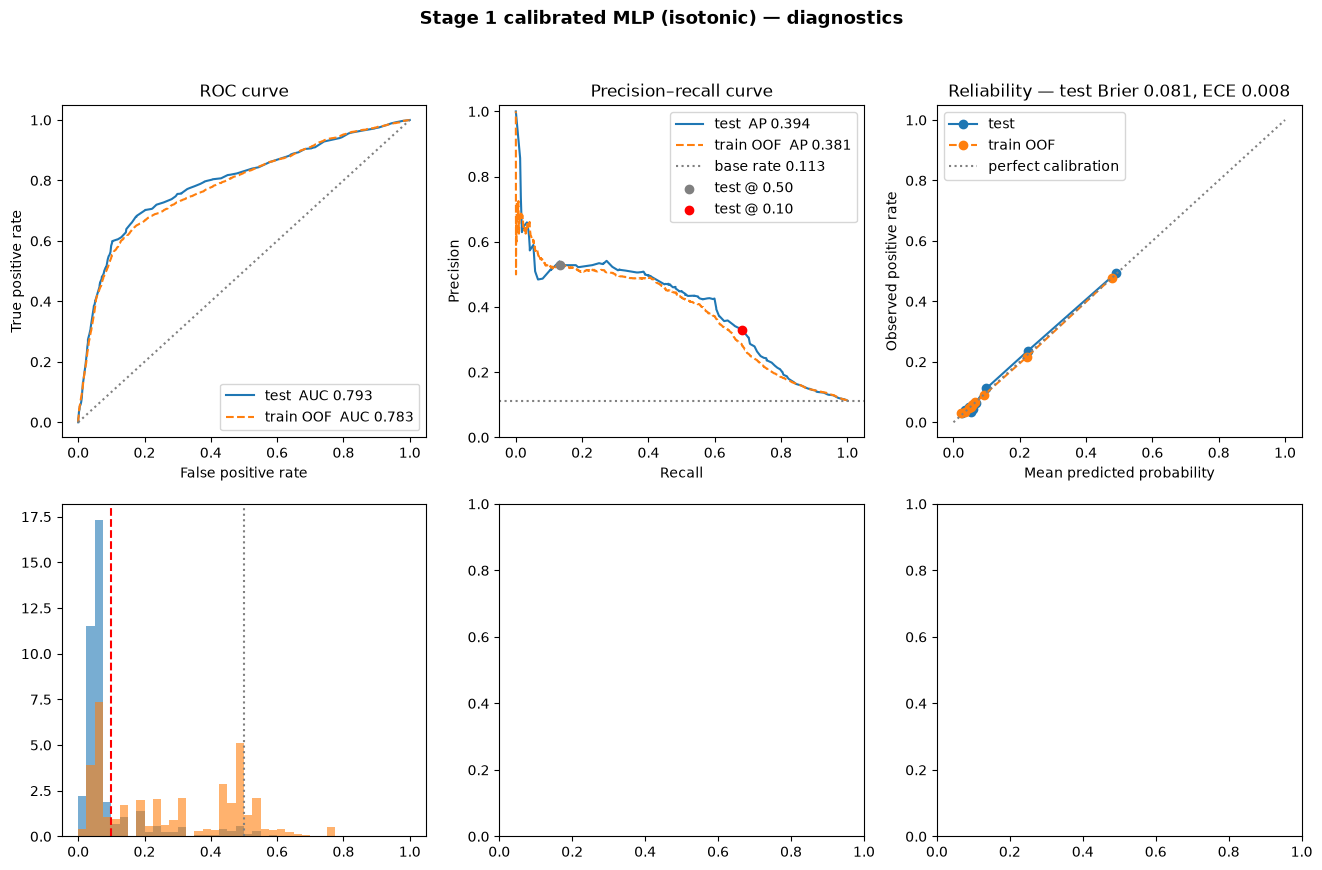

In [15]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, roc_curve

thr = stage1.optimal_threshold
y_te, p_te = STAGE1["y_test"], STAGE1_OUTPUT["proba_test"]
y_tr, p_oof = STAGE1["y_train"], STAGE1_OUTPUT["proba_train_oof"]
m_te_05  = stage1_metrics.loc["test @ 0.50"]
m_te_thr = stage1_metrics.loc[f"test @ {thr:.2f}"]
m_tr_05  = stage1_metrics.loc["train OOF @ 0.50"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))
fig.suptitle(f"Stage 1 calibrated MLP ({stage1.calibration_method}) — diagnostics",
             fontsize=13, fontweight="bold")

# ROC
ax = axes[0, 0]
for label, yy, pp, ls, m in (("test", y_te, p_te, "-", m_te_05), ("train OOF", y_tr, p_oof, "--", m_tr_05)):
    fpr, tpr, _ = roc_curve(yy, pp)
    ax.plot(fpr, tpr, ls, label=f"{label}  AUC {m['roc_auc']:.3f}")
ax.plot([0, 1], [0, 1], ":", color="grey")
ax.set(title="ROC curve", xlabel="False positive rate", ylabel="True positive rate")
ax.legend(loc="lower right")

# Precision-recall
ax = axes[0, 1]
for label, yy, pp, ls, m in (("test", y_te, p_te, "-", m_te_05), ("train OOF", y_tr, p_oof, "--", m_tr_05)):
    prec, rec, _ = precision_recall_curve(yy, pp)
    ax.plot(rec, prec, ls, label=f"{label}  AP {m['pr_auc']:.3f}")
ax.axhline(y_te.mean(), ls=":", color="grey", label=f"base rate {y_te.mean():.3f}")
ax.scatter(m_te_05["recall"], m_te_05["precision"], color="grey", zorder=5, label="test @ 0.50")
ax.scatter(m_te_thr["recall"], m_te_thr["precision"], color="red", zorder=5, label=f"test @ {thr:.2f}")
ax.set(title="Precision–recall curve", xlabel="Recall", ylabel="Precision", ylim=(0, 1.02))
ax.legend(loc="upper right")

# Reliability (calibrated)
ax = axes[0, 2]
for label, yy, pp, ls in (("test", y_te, p_te, "-"), ("train OOF", y_tr, p_oof, "--")):
    frac_pos, mean_pred = calibration_curve(yy, pp, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o" + ls, label=label)
ax.plot([0, 1], [0, 1], ":", color="grey", label="perfect calibration")
ax.set(title=f"Reliability — test Brier {m_te_05['brier']:.3f}, ECE {m_te_05['ece']:.3f}",
       xlabel="Mean predicted probability", ylabel="Observed positive rate")
ax.legend(loc="upper left")

# Probability distribution by class
ax = axes[1, 0]
bins = np.linspace(0, 1, 41)
ax.hist(p_te[y_te == 0], bins=bins, alpha=0.6, density=True, label="y = 0")
ax.hist(p_te[y_te == 1], bins=bins, alpha=0.6, density=True, label="y = 1")
ax.axvline(0.5, color="grey", ls=":", label="0.50")
ax.axvline(thr, color="red", ls="--", label=f"CV threshold {thr:.2f}")

In [ ]:
# ---------------------------------------------------------------------------
# Decision threshold
# ---------------------------------------------------------------------------

from typing import Optional, Tuple
from sklearn.metrics import fbeta_score

def tune_threshold(
    y_true: pd.Series,
    proba: pd.Series,
    beta: float = 2.0,
    grid: Optional[np.ndarray] = None,
) -> Tuple[float, pd.DataFrame]:
    """Threshold maximising F-beta. Pass training (OOF) probabilities only."""
    y = np.asarray(y_true).astype(int)
    p = np.asarray(proba, dtype=float)
    grid = np.round(np.arange(0.05, 0.951, 0.005), 3) if grid is None else np.asarray(grid)
    scores = np.array([
        fbeta_score(y, (p >= t).astype(int), beta=beta, zero_division=0) for t in grid
    ])
    best = int(np.argmax(scores))
    return float(grid[best]), pd.DataFrame({"threshold": grid, "f_beta": scores})

Stage 1 tuned threshold (max F2 on training OOF): 0.455
                   precision  recall      f1      f2  roc_auc  pr_auc   brier  pred_pos_rate
train OOF @ 0.5       0.3258  0.6360  0.4309  0.5343   0.7811  0.3700  0.1677         0.2199
test @ 0.5            0.3532  0.6315  0.4530  0.5455   0.7924  0.3843  0.1592         0.2014
train OOF @ 0.455     0.3157  0.6482  0.4246  0.5354   0.7811  0.3700  0.1677         0.2313
test @ 0.455          0.3400  0.6616  0.4492  0.5564   0.7924  0.3843  0.1592         0.2192


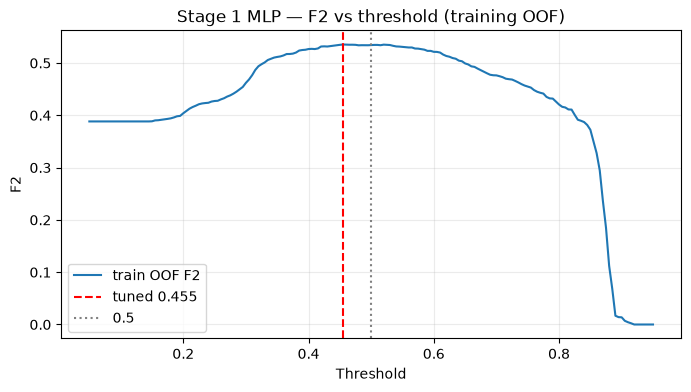

In [ ]:
import importlib
import blackbox_pipeline.models.stage1_mlp as stage1_mlp
importlib.reload(stage1_mlp)  # picks up tune_threshold without restarting the kernel

STAGE1_THRESHOLD, stage1_threshold_curve = stage1_mlp.tune_threshold(
    STAGE1["y_train"], STAGE1_OUTPUT["proba_train_oof"], beta=2.0,
)

STAGE1_OUTPUT["threshold"]      = STAGE1_THRESHOLD
STAGE1_OUTPUT["pred_train_oof"] = (STAGE1_OUTPUT["proba_train_oof"] >= STAGE1_THRESHOLD).astype("int8")
STAGE1_OUTPUT["pred_test"]      = (STAGE1_OUTPUT["proba_test"] >= STAGE1_THRESHOLD).astype("int8")

stage1_metrics = pd.DataFrame({
    "train OOF @ 0.5":                     stage1_mlp.binary_metrics(STAGE1["y_train"], STAGE1_OUTPUT["proba_train_oof"], 0.5),
    "test @ 0.5":                          stage1_mlp.binary_metrics(STAGE1["y_test"],  STAGE1_OUTPUT["proba_test"], 0.5),
    f"train OOF @ {STAGE1_THRESHOLD:.3f}": stage1_mlp.binary_metrics(STAGE1["y_train"], STAGE1_OUTPUT["proba_train_oof"], STAGE1_THRESHOLD),
    f"test @ {STAGE1_THRESHOLD:.3f}":      stage1_mlp.binary_metrics(STAGE1["y_test"],  STAGE1_OUTPUT["proba_test"], STAGE1_THRESHOLD),
}).T

print(f"Stage 1 tuned threshold (max F2 on training OOF): {STAGE1_THRESHOLD:.3f}")
print(stage1_metrics.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(stage1_threshold_curve["threshold"], stage1_threshold_curve["f_beta"], label="train OOF F2")
ax.axvline(STAGE1_THRESHOLD, color="red", ls="--", label=f"tuned {STAGE1_THRESHOLD:.3f}")
ax.axvline(0.5, color="grey", ls=":", label="0.5")
ax.set(title="Stage 1 MLP — F2 vs threshold (training OOF)", xlabel="Threshold", ylabel="F2")
ax.grid(alpha=0.25); ax.legend()
plt.show()